In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import binom
from scipy.special import comb

import ast


In [3]:
dfWLO = pd.read_csv('/Users/daksheshkaran/Win-Loss-Sequences-Sp2026/code/soccer_binary.csv')
dfWLO.head()

,Season,Team,Sequence,League
0,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",D1
1,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",D1
2,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",D1
3,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",D1
4,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",D1


In [5]:
dfWLO['Sequence'] = dfWLO['Sequence'].apply(ast.literal_eval)

In [7]:
dfWLO['League'] = dfWLO['League'].replace("E0", "Premier_League")
dfWLO['League'] = dfWLO['League'].replace("D1", "Bundesliga")
dfWLO['League'] = dfWLO['League'].replace("SP1", "La_Liga")

In [9]:
dfWLO['Sequence'].str.len()

0       28
1       28
2       31
3       24
4       29
        ..
1433    31
1434    25
1435    34
1436    25
1437    28
Name: Sequence, Length: 1438, dtype: int64

In [11]:
dfWLO['Total_Games'] = dfWLO['Sequence'].str.len()
dfWLO

,Season,Team,Sequence,League,Total_Games
0,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",Bundesliga,28
1,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",Bundesliga,28
2,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",Bundesliga,31
3,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",Bundesliga,24
4,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",Bundesliga,29
...,...,...,...,...,...
1433,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",La_Liga,31
1434,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",La_Liga,25
1435,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",La_Liga,34
1436,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",La_Liga,25


In [13]:
dfWLO['Wins'] = dfWLO['Sequence'].apply(sum)
dfWLO

,Season,Team,Sequence,League,Total_Games,Wins
0,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",Bundesliga,28,19
1,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",Bundesliga,28,7
2,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",Bundesliga,31,12
3,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",Bundesliga,24,16
4,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",Bundesliga,29,10
...,...,...,...,...,...,...
1433,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",La_Liga,31,13
1434,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",La_Liga,25,11
1435,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",La_Liga,34,4
1436,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",La_Liga,25,13


In [15]:
dfWLO['Lower_Tail'] = binom.cdf(dfWLO['Wins'], dfWLO['Total_Games'], 0.5)
dfWLO['Upper_Tail'] = 1 -binom.cdf(dfWLO['Wins'], dfWLO['Total_Games'], 0.5) + comb(dfWLO['Total_Games'], dfWLO['Wins']) / (2 ** dfWLO['Wins'])
dfWLO['WOAT_Score'] = 1/dfWLO['Lower_Tail']
dfWLO['GOAT_Score'] = 1/dfWLO['Upper_Tail']

In [17]:
dfWLO

,Season,Team,Sequence,League,Total_Games,Wins,Lower_Tail,Upper_Tail,WOAT_Score,GOAT_Score
0,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",Bundesliga,28,19,0.982151,13.191715,1.018173,0.075805
1,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",Bundesliga,28,7,0.006270,9251.306230,159.477534,0.000108
2,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",Bundesliga,31,12,0.140521,34454.112653,7.116386,0.000029
3,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",Bundesliga,24,16,0.968043,11.254354,1.033012,0.088854
4,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",Bundesliga,29,10,0.068023,19561.488618,14.700916,0.000051
...,...,...,...,...,...,...,...,...,...,...
1433,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",La_Liga,31,13,0.236565,25178.140755,4.227171,0.000040
1434,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",La_Liga,25,11,0.345019,2177.119825,2.898391,0.000459
1435,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",La_Liga,34,4,0.000003,2899.499997,324417.803157,0.000345
1436,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",La_Liga,25,13,0.654981,635.147265,1.526762,0.001574


In [19]:
max = dfWLO['GOAT_Score'].max()
dfWLO[dfWLO['GOAT_Score']==max]

,Season,Team,Sequence,League,Total_Games,Wins,Lower_Tail,Upper_Tail,WOAT_Score,GOAT_Score
424,2023,Leverkusen,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",Bundesliga,28,28,1.0,3.725290e-09,1.0,268435456.0


In [21]:
maxW = dfWLO['WOAT_Score'].max()
dfWLO[dfWLO['WOAT_Score']==maxW]

,Season,Team,Sequence,League,Total_Games,Wins,Lower_Tail,Upper_Tail,WOAT_Score,GOAT_Score
597,2007,Derby,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Premier_League,30,1,2.887100e-08,16.0,3.463683e+07,0.0625


In [23]:
#Top 10 GOAT Scores

dfWLO.nlargest(10, "GOAT_Score")[["Team", "Season", "League", "GOAT_Score"]]


,Team,Season,League,GOAT_Score
424,Leverkusen,2023,Bundesliga,2.684355e+08
1118,Barcelona,2009,La_Liga,6.607642e+07
822,Liverpool,2018,Premier_League,3.408704e+07
217,Bayern Munich,2012,Bundesliga,1.760232e+07
1412,Real Madrid,2023,La_Liga,1.760232e+07
840,Liverpool,2019,Premier_League,9.099507e+06
1278,Barcelona,2017,La_Liga,9.099507e+06
801,Man City,2017,Premier_League,7.538337e+06
1166,Real Madrid,2011,La_Liga,7.538337e+06
1177,Barcelona,2012,La_Liga,7.538337e+06


In [25]:
#Top 10 WOAT Scores

dfWLO.nlargest(10, "WOAT_Score")[["Team", "Season", "League", "WOAT_Score"]]

,Team,Season,League,WOAT_Score
597,Derby,2007,Premier_League,3.463683e+07
951,Southampton,2024,Premier_League,8.119031e+06
566,Sunderland,2005,Premier_League,7.824681e+05
820,Huddersfield,2018,Premier_League,4.301850e+05
930,Sheffield United,2023,Premier_League,4.301850e+05
1435,Valladolid,2024,La_Liga,3.244178e+05
752,Aston Villa,2015,Premier_League,2.372386e+05
507,Sunderland,2002,Premier_League,5.890456e+04
373,Schalke 04,2020,Bundesliga,4.062280e+04
1220,Cordoba,2014,La_Liga,4.062280e+04


In [27]:
dfWLO['log_GOAT'] = np.log(dfWLO['GOAT_Score'])
dfWLO['log_WOAT'] = np.log(dfWLO['WOAT_Score'])



In [29]:
dfWLO

,Season,Team,Sequence,League,Total_Games,Wins,Lower_Tail,Upper_Tail,WOAT_Score,GOAT_Score,log_GOAT,log_WOAT
0,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",Bundesliga,28,19,0.982151,13.191715,1.018173,0.075805,-2.579589,0.018010
1,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",Bundesliga,28,7,0.006270,9251.306230,159.477534,0.000108,-9.132520,5.071903
2,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",Bundesliga,31,12,0.140521,34454.112653,7.116386,0.000029,-10.447384,1.962400
3,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",Bundesliga,24,16,0.968043,11.254354,1.033012,0.088854,-2.420755,0.032479
4,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",Bundesliga,29,10,0.068023,19561.488618,14.700916,0.000051,-9.881318,2.687910
...,...,...,...,...,...,...,...,...,...,...,...,...
1433,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",La_Liga,31,13,0.236565,25178.140755,4.227171,0.000040,-10.133731,1.441533
1434,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",La_Liga,25,11,0.345019,2177.119825,2.898391,0.000459,-7.685758,1.064156
1435,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",La_Liga,34,4,0.000003,2899.499997,324417.803157,0.000345,-7.972294,12.689787
1436,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",La_Liga,25,13,0.654981,635.147265,1.526762,0.001574,-6.453857,0.423149


In [33]:
top10_GOAT = dfWLO.nlargest(10, "GOAT_Score")[["Team", "Season", "League", "GOAT_Score", "log_GOAT"]]
top10_GOAT

,Team,Season,League,GOAT_Score,log_GOAT
424,Leverkusen,2023,Bundesliga,2.684355e+08,19.408121
1118,Barcelona,2009,La_Liga,6.607642e+07,18.006323
822,Liverpool,2018,Premier_League,3.408704e+07,17.344428
217,Bayern Munich,2012,Bundesliga,1.760232e+07,16.683542
1412,Real Madrid,2023,La_Liga,1.760232e+07,16.683542
840,Liverpool,2019,Premier_League,9.099507e+06,16.023731
1278,Barcelona,2017,La_Liga,9.099507e+06,16.023731
801,Man City,2017,Premier_League,7.538337e+06,15.835512
1166,Real Madrid,2011,La_Liga,7.538337e+06,15.835512
1177,Barcelona,2012,La_Liga,7.538337e+06,15.835512


In [37]:
top10_GOAT['Team_Name'] = top10_GOAT['Season'].astype(str) + ' ' + top10_GOAT['Team']
top10_GOAT

,Team,Season,League,GOAT_Score,log_GOAT,Team_Name
424,Leverkusen,2023,Bundesliga,2.684355e+08,19.408121,2023 Leverkusen
1118,Barcelona,2009,La_Liga,6.607642e+07,18.006323,2009 Barcelona
822,Liverpool,2018,Premier_League,3.408704e+07,17.344428,2018 Liverpool
217,Bayern Munich,2012,Bundesliga,1.760232e+07,16.683542,2012 Bayern Munich
1412,Real Madrid,2023,La_Liga,1.760232e+07,16.683542,2023 Real Madrid
840,Liverpool,2019,Premier_League,9.099507e+06,16.023731,2019 Liverpool
1278,Barcelona,2017,La_Liga,9.099507e+06,16.023731,2017 Barcelona
801,Man City,2017,Premier_League,7.538337e+06,15.835512,2017 Man City
1166,Real Madrid,2011,La_Liga,7.538337e+06,15.835512,2011 Real Madrid
1177,Barcelona,2012,La_Liga,7.538337e+06,15.835512,2012 Barcelona


## Bar chart of top 10 most impressive season/team pairs

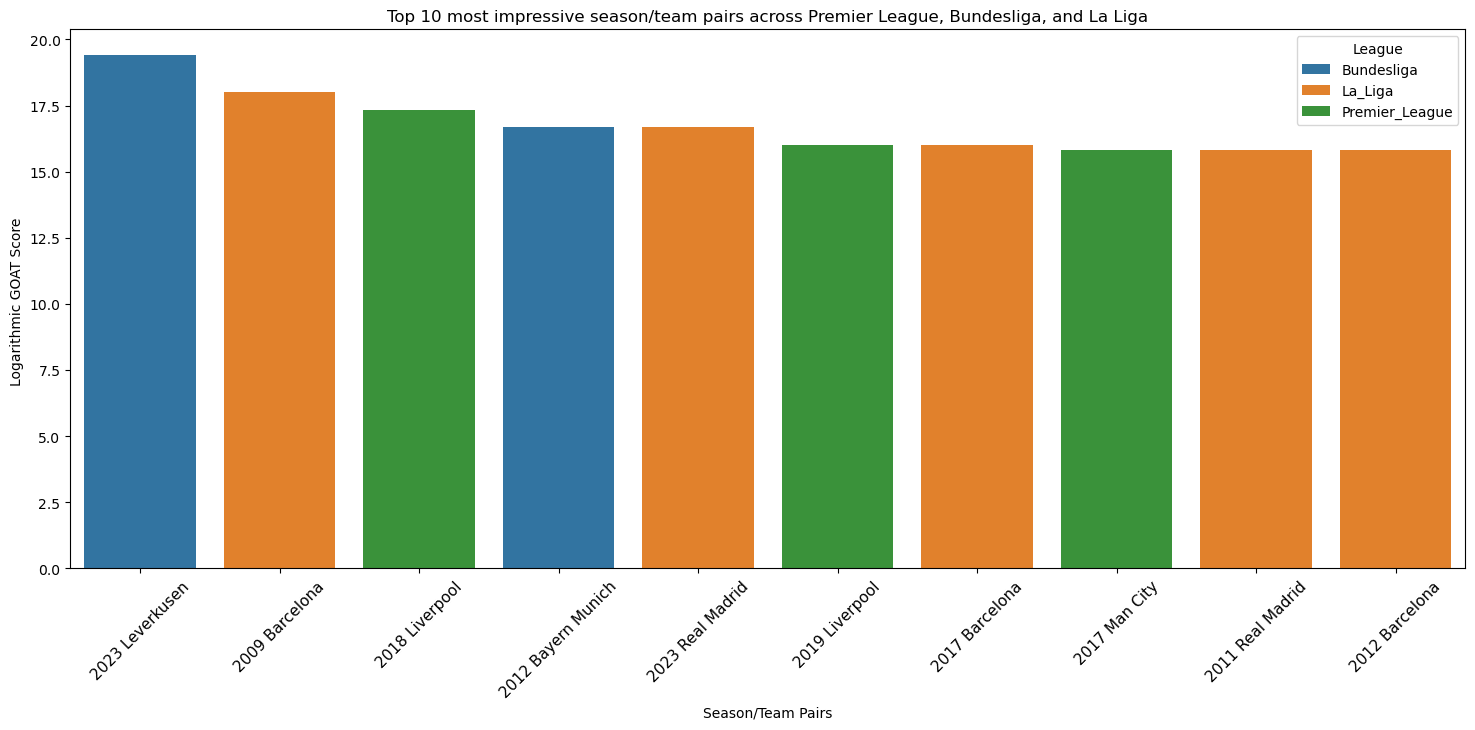

In [53]:
plt.figure(figsize=(18,7))

sns.barplot(x=top10_GOAT['Team_Name'], y = top10_GOAT['log_GOAT'], palette = 'tab10', hue = top10_GOAT['League'])
plt.title('Top 10 most impressive season/team pairs across Premier League, Bundesliga, and La Liga')
plt.xlabel('Season/Team Pairs')
plt.ylabel('Logarithmic GOAT Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

## Histogram for Premier League GOAT Scores

In [59]:
premier_league_df = dfWLO[dfWLO['League']=='Premier_League']
premier_league_goat = premier_league_df[['Season', 'Team', 'League', 'GOAT_Score', 'log_GOAT']]
premier_league_goat

,Season,Team,League,GOAT_Score,log_GOAT
451,2000,Arsenal,Premier_League,0.336656,-1.088693
452,2000,Aston Villa,Premier_League,0.007150,-4.940634
453,2000,Bradford,Premier_League,0.000396,-7.833526
454,2000,Charlton,Premier_League,0.000408,-7.803414
455,2000,Chelsea,Premier_League,0.006100,-5.099424
...,...,...,...,...,...
950,2024,Nottm Forest,Premier_League,0.693180,-0.366466
951,2024,Southampton,Premier_League,0.008000,-4.828314
952,2024,Tottenham,Premier_League,0.000011,-11.456369
953,2024,West Ham,Premier_League,0.000095,-9.257822


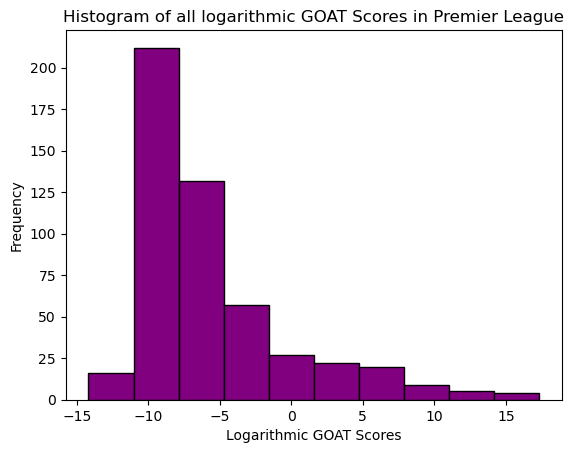

In [93]:
plt.hist(premier_league_goat['log_GOAT'], color='purple', edgecolor='black') 
plt.title('Histogram of all logarithmic GOAT Scores in Premier League')
plt.xlabel('Logarithmic GOAT Scores')
plt.ylabel('Frequency')
plt.show()

## Histogram for all Bundesliga GOAT Scores

In [66]:
bundesliga_df = dfWLO[dfWLO['League']=='Bundesliga']
bundesliga_goat = bundesliga_df[['Season', 'Team', 'League', 'GOAT_Score', 'log_GOAT']]
bundesliga_goat

,Season,Team,League,GOAT_Score,log_GOAT
0,2000,Bayern Munich,Bundesliga,0.075805,-2.579589
1,2000,Bochum,Bundesliga,0.000108,-9.132520
2,2000,Cottbus,Bundesliga,0.000029,-10.447384
3,2000,Dortmund,Bundesliga,0.088854,-2.420755
4,2000,Ein Frankfurt,Bundesliga,0.000051,-9.881318
...,...,...,...,...,...
446,2024,St Pauli,Bundesliga,0.000164,-8.716634
447,2024,Stuttgart,Bundesliga,0.001696,-6.379678
448,2024,Union Berlin,Bundesliga,0.000895,-7.019219
449,2024,Werder Bremen,Bundesliga,0.003673,-5.606795


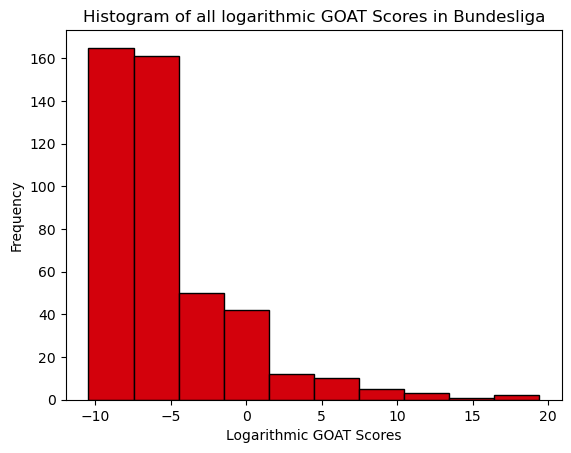

In [89]:
plt.hist(bundesliga_goat['log_GOAT'], color='#D3010C', edgecolor='black') 
plt.title('Histogram of all logarithmic GOAT Scores in Bundesliga')
plt.xlabel('Logarithmic GOAT Scores')
plt.ylabel('Frequency')
plt.show()

## Histogram for all La Liga GOAT Scores

In [75]:
la_liga_df = dfWLO[dfWLO['League']=='La_Liga']
la_liga_goat = la_liga_df[['Season', 'Team', 'League', 'GOAT_Score', 'log_GOAT']]
la_liga_goat

,Season,Team,League,GOAT_Score,log_GOAT
955,2000,Alaves,La_Liga,0.000062,-9.691908
956,2000,Ath Bilbao,La_Liga,0.000095,-9.257822
957,2000,Barcelona,La_Liga,0.041883,-3.172881
958,2000,Celta,La_Liga,0.005023,-5.293638
959,2000,Espanol,La_Liga,0.000113,-9.091159
...,...,...,...,...,...
1433,2024,Sociedad,La_Liga,0.000040,-10.133731
1434,2024,Valencia,La_Liga,0.000459,-7.685758
1435,2024,Valladolid,La_Liga,0.000345,-7.972294
1436,2024,Vallecano,La_Liga,0.001574,-6.453857


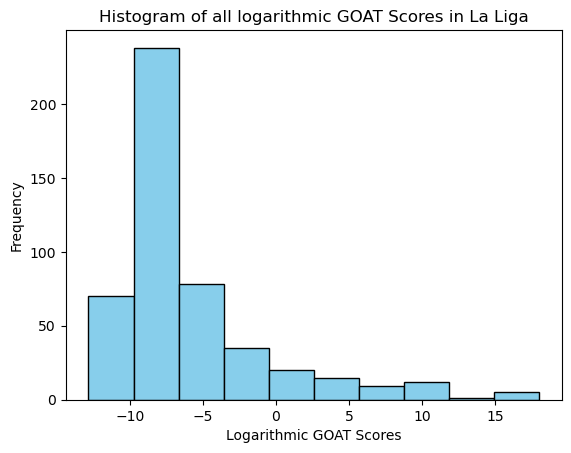

In [97]:
plt.hist(la_liga_goat['log_GOAT'], color='skyblue', edgecolor='black') 
plt.title('Histogram of all logarithmic GOAT Scores in La Liga')
plt.xlabel('Logarithmic GOAT Scores')
plt.ylabel('Frequency')
plt.show()